<a href="https://colab.research.google.com/github/AndrewLoweUoM/NFM/blob/main/Multiple_Event_Analysis_Average_Hydrographs__Lags.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Description of Code:

This script performs multi-event hydrological analysis on flow hydrographs, with a focus on:

* Comparing multiple storm events
* Creating a composite (average) hydrograph
* Estimating lag time between rainfall and flow
* Quantifying uncertainty (confidence intervals).


This code implements event-based hydrological analysis as follows:

 * Load multi-event rainfall–runoff data
 * Visualise variability across storms
 * Derive a representative (average) hydrograph
 * Extract key metrics:
   * Peak flow
   * Peak rainfall
   * Lag time
   * Quantify uncertainty using confidence intervals
   * Export results.


 The script performs multi-event rainfall–runoff analysis and builds a composite hydrograph using using simple averaging (mean hydrograph), to estimate peak behaviour, lag time, and uncertainty in rainfall–runoff response.

# Data Loading



#### Prepare and load data into Dataframe

In [ ]:
# Load the data using pandas
import pandas as pd # pandas for data manipulation
import matplotlib.pyplot as plt # import the pyplot module from matplotlib
from matplotlib.dates import DateFormatter
import numpy as np # numpy for numerical operations

# Load the event data for all events
file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Adjusted/Bollin_storm_event_timeseries_all_events_adjusted.csv'
# Load the event data for events before NFM
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Adjusted/Bollin_storm_event_timeseries_all_events_adjusted_before.csv'
# Load the event data for events after NFM
# file_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Input/Events/Adjusted/Bollin_storm_event_timeseries_all_events_adjusted_after.csv.csv'

df_events = pd.read_csv(file_path)
# Displays start data in the Dataframe
df_events.head()

,Time,Event001_Time,Event001_Stage_m,Event001_Flow_m3s,Event001_Rain_mm,Event002_Time,Event002_Stage_m,Event002_Flow_m3s,Event002_Rain_mm,Event003_Time,...,Event049_Flow_m3s,Event049_Rain_mm,Event050_Time,Event050_Stage_m,Event050_Flow_m3s,Event050_Rain_mm,Event051_Time,Event051_Stage_m,Event051_Flow_m3s,Event051_Rain_mm
0,1,03/05/2021 09:00,0.315,2.228,0.10,21/05/2021 07:00,0.443,4.515,0.05,04/07/2021 09:45,...,1.719,0.01,27/09/2025 20:15,0.277,1.773,0.10,03/10/2025 07:00,0.326,2.435,0.01
1,2,03/05/2021 09:15,0.314,2.228,0.05,21/05/2021 07:15,0.443,4.451,0.10,04/07/2021 10:00,...,1.746,0.01,27/09/2025 20:30,0.277,1.787,0.47,03/10/2025 07:15,0.327,2.466,0.00
2,3,03/05/2021 09:30,0.314,2.228,0.00,21/05/2021 07:30,0.442,4.451,0.11,04/07/2021 10:15,...,1.733,0.00,27/09/2025 20:45,0.278,1.760,1.04,03/10/2025 07:30,0.329,2.482,0.00
3,4,03/05/2021 09:45,0.314,2.244,0.00,21/05/2021 07:45,0.440,4.451,0.16,04/07/2021 10:30,...,1.733,0.07,27/09/2025 21:00,0.277,1.760,0.47,03/10/2025 07:45,0.330,2.482,0.00
4,5,03/05/2021 10:00,0.315,2.228,0.11,21/05/2021 08:00,0.439,4.367,0.00,04/07/2021 10:45,...,1.746,0.07,27/09/2025 21:15,0.277,1.828,0.12,03/10/2025 08:00,0.330,2.498,0.00


# Multi-Event Visualisation

### Specify the Number of Events and Specify Time Intervals

In [ ]:
# Number of flood hydrograph events (Event 1 assigned Event ID 0 e.g. for 53 events N = 52 )
N = 52
# Time interval of data
T= 15
# Hourly sub-units
time_units_hour = 60/T

print(f'Number of Events: {N}')
print(f'Time Interval: {T} minutes')
print(f'Time units per hours: {time_units_hour}')

Number of Events: 52
Time Interval: 15 minutes
Time units per hours: 4.0


### Multi Event Hydrograph

Flow plot:

* Loops through all `*_Flow_m3s` columns
* Plots all hydrographs on the same axes

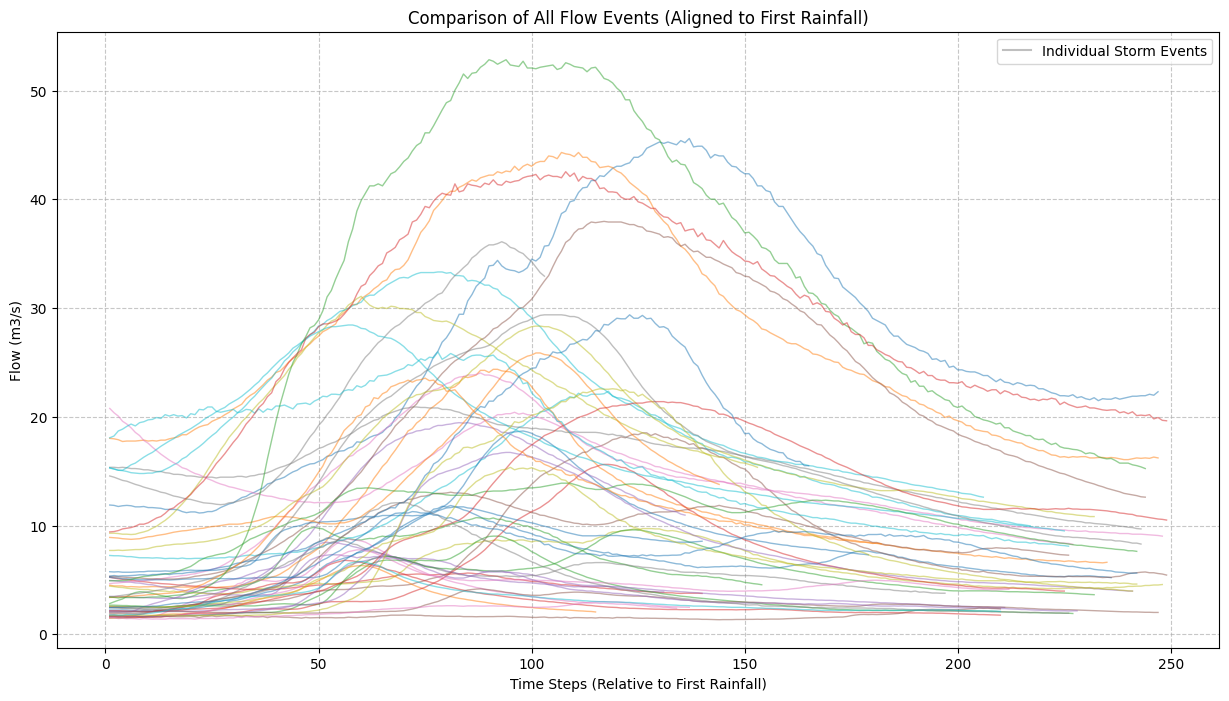

In [ ]:
import matplotlib.pyplot as plt

# Create a figure for the plot
plt.figure(figsize=(15, 8))

# Identify flow columns in the adjusted dataframe
flow_cols = [col for col in df_events.columns if col.endswith('_Flow_m3s')]

# Loop through and plot each event's flow
for col in flow_cols:
    # We plot against the 'Time' column which now represents relative steps from start of rain
    plt.plot(df_events['Time'], df_events[col], alpha=0.5, linewidth=1, label='_nolegend_')

# Add labels and title
plt.xlabel('Time Steps (Relative to First Rainfall)')
plt.ylabel('Flow (m3/s)')
plt.title('Comparison of All Flow Events (Aligned to First Rainfall)')

# Add a grid for readability
plt.grid(True, linestyle='--', alpha=0.7)

# Add a generic legend entry for the events
plt.plot([], [], color='gray', alpha=0.5, label='Individual Storm Events')
plt.legend()

plt.show()

### Multi Event Rainfall Plot

Rainfall plot:

* loops using `*_Rain_mm`
* Uses bar charts to show rainfall pulses


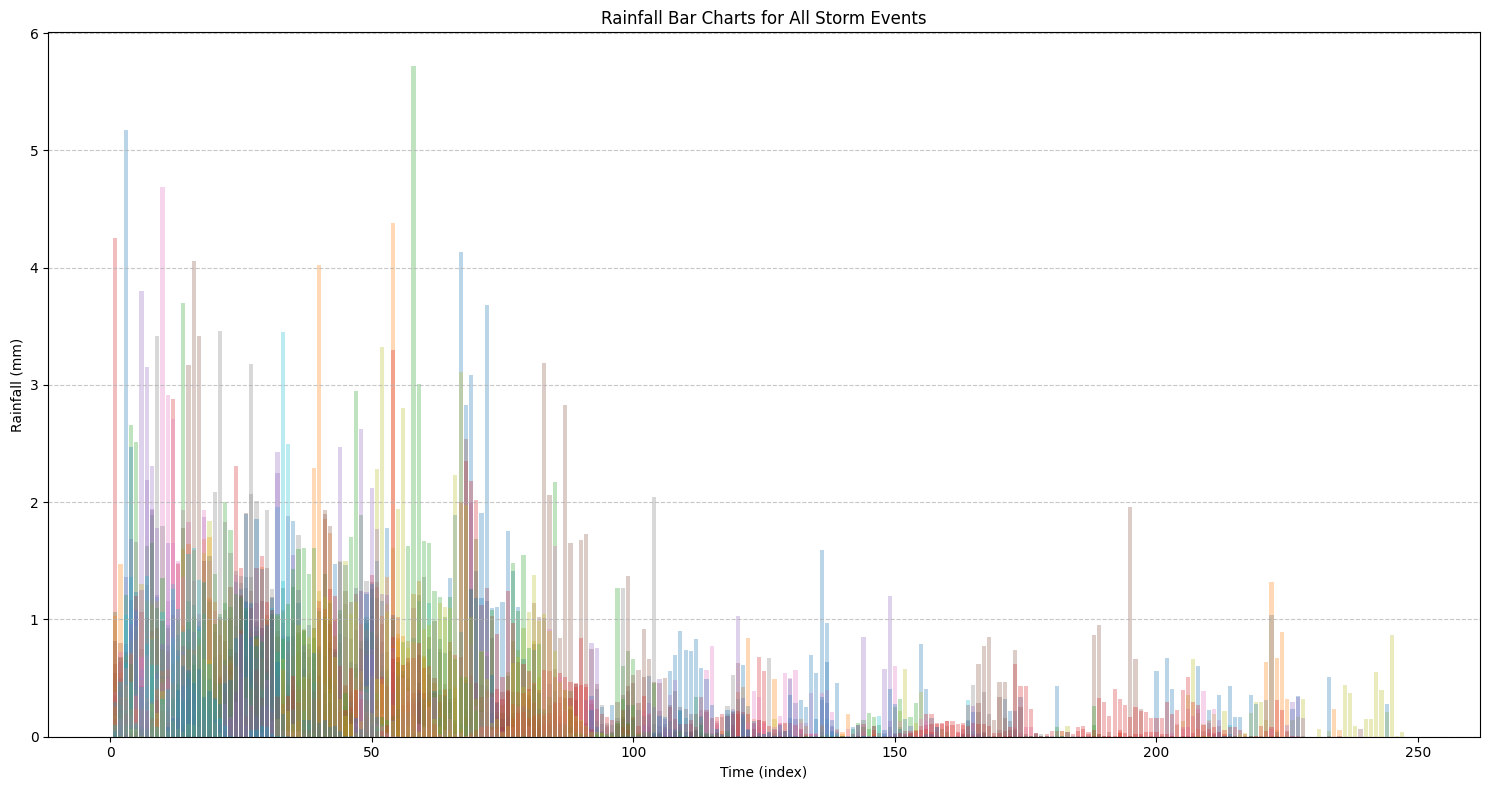

In [ ]:
import matplotlib.pyplot as plt

# Filter for rainfall columns
rain_columns = [col for col in df_events.columns if col.endswith('_Rain_mm')]

# Create a figure
plt.figure(figsize=(15, 8))

# Plot each event's rainfall as a bar chart
for col in rain_columns:
    plt.bar(df_events['Time'], df_events[col], alpha=0.3, label='_nolegend_')

plt.title('Rainfall Bar Charts for All Storm Events')
plt.xlabel('Time (index)')
plt.ylabel('Rainfall (mm)')
#plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Average (Composite) Hydrograph Creation

* Identifies all flow and rainfall columns
* Computes row-wise mean

### Average Flow and Rainfall Profiles


Compute the row-wise mean for all identified flow and rainfall columns to create composite 'Average_Flow' and 'Average_Rain' series.


In [ ]:
flow_columns = [col for col in df_events.columns if col.endswith('_Flow_m3s')]
rain_columns = [col for col in df_events.columns if col.endswith('_Rain_mm')]

# Calculate row-wise mean for flow and rainfall columns
df_events['Average_Flow'] = df_events[flow_columns].mean(axis=1)
df_events['Average_Rain'] = df_events[rain_columns].mean(axis=1)

# Display the 'Time' and calculated averages to verify
print('Verification of Average Profiles:')
print(df_events[['Time', 'Average_Flow', 'Average_Rain']].head())

# Check for any remaining nulls in the new columns if necessary
print('\nNull values in Average_Flow:', df_events['Average_Flow'].isnull().sum())
print('Null values in Average_Rain:', df_events['Average_Rain'].isnull().sum())

Verification of Average Profiles:
   Time  Average_Flow  Average_Rain
0     1      5.576373      0.271176
1     2      5.565059      0.257255
2     3      5.552157      0.362941
3     4      5.541627      0.377059
4     5      5.546137      0.320588

Null values in Average_Flow: 0
Null values in Average_Rain: 0


### Create DataFrame for Average Flow and Average Rainfall from All Events

In [ ]:
# Create a new DataFrame with only the required average columns for flow and rainfall
df_events_average = df_events[['Time', 'Average_Flow', 'Average_Rain']].copy()
df_events_average.head()

,Time,Average_Flow,Average_Rain
0,1,5.576373,0.271176
1,2,5.565059,0.257255
2,3,5.552157,0.362941
3,4,5.541627,0.377059
4,5,5.546137,0.320588


# Average Hydrograph Plot

#### Plot Average Rainfal and Average Hydrograph vs Time Index



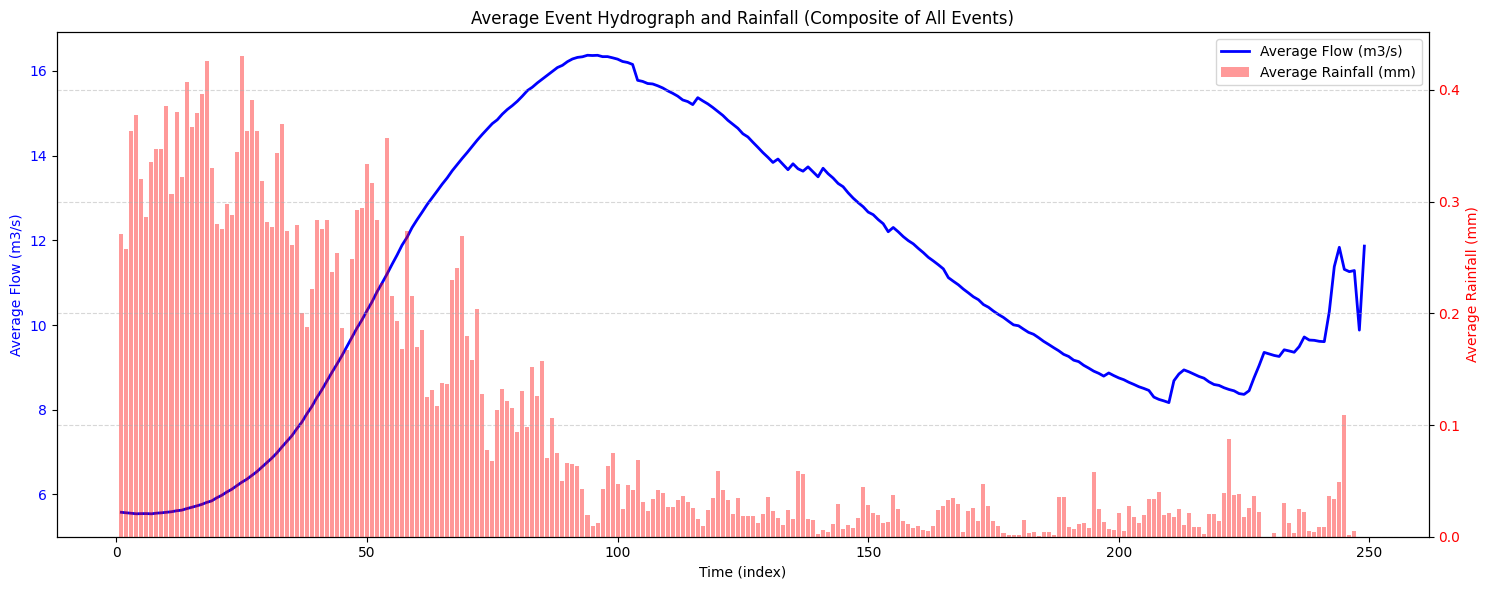

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot 'Average_Flow' on the primary y-axis (ax1)
# line_flow, = ax1.plot(df_events['Time'], df_events['Average_Flow'], color='blue', label='Average Flow (m3/s)', linewidth=2)
line_flow, = ax1.plot(df_events_average['Time'], df_events_average['Average_Flow'], color='blue', label='Average Flow (m3/s)', linewidth=2)
ax1.set_xlabel('Time (index)')
ax1.set_ylabel('Average Flow (m3/s)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a secondary y-axis (ax2) for rainfall
ax2 = ax1.twinx()
#bar_rain = ax2.bar(df_events['Time'], df_events['Average_Rain'], color='red', alpha=0.4, label='Average Rainfall (mm)')
bar_rain = ax2.bar(df_events_average['Time'], df_events_average['Average_Rain'], color='red', alpha=0.4, label='Average Rainfall (mm)')
ax2.set_ylabel('Average Rainfall (mm)', color='red')
ax2.tick_params(axis='y', labelcolor='red')


# Add title
plt.title('Average Event Hydrograph and Rainfall (Composite of All Events)')

# Combine legends from both axes
lines = [line_flow, bar_rain]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.grid(True, which='both', linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()

# Peak Analysis (Average Event)

Calculates:
* Peak flow value and timing
* Peak rainfall value and timing
* Converts time index → hours

In [ ]:
# Find peak flow value
peak_avg_flow_value = df_events_average['Average_Flow'].max()

# Find time index of peak flow
peak_avg_flow_idx = df_events_average['Average_Flow'].idxmax()
peak_avg_flow_time = df_events_average.loc[peak_avg_flow_idx, 'Time']

# Find peak rainfall value and its time index
peak_avg_rain_value = df_events_average['Average_Rain'].max()
peak_avg_rain_idx = df_events_average['Average_Rain'].idxmax()
peak_avg_rain_time = df_events_average.loc[peak_avg_rain_idx, 'Time']

# Print results to verify
print(f'Average Flow Peak: {peak_avg_flow_value:.2f} m3/s at Time Index: {peak_avg_flow_time}')
print(f'Average Rainfall Peak: {peak_avg_rain_value:.2f} mm at Time Index: {peak_avg_rain_time}')

Average Flow Peak: 16.37 m3/s at Time Index: 94
Average Rainfall Peak: 0.43 mm at Time Index: 25


### Calculate Peak Value and Timing for Average Hyrograph and Average Rainfall (Hours)

In [ ]:
# Time interval of input data which is 15 minutes
time_interval_min = T

# Convert from Time Index to Hours
peak_avg_flow_time_hours = (peak_avg_flow_time * time_interval_min) / 60
peak_avg_rain_time_hours = (peak_avg_rain_time * time_interval_min) / 60

# Print results to verify
print(f'Average Flow Peak: {peak_avg_flow_value:.2f} m3/s at Time: {peak_avg_flow_time_hours:.2f} hours (from start)')
print(f'Average Rainfall Peak: {peak_avg_rain_value:.2f} mm at Time: {peak_avg_rain_time_hours:.2f} hours (from start)')

Average Flow Peak: 16.37 m3/s at Time: 23.50 hours (from start)
Average Rainfall Peak: 0.43 mm at Time: 6.25 hours (from start)


# Plot Average Hydrograph

In [ ]:
print(f'Time units per hour: {time_units_hour}')

# Convert Time Index to hourly by dividing by time interval of 4 (4 units of 15 mins in 1 hour)
x_axis_values = df_events_average['Time'] / time_units_hour
min_x = x_axis_values.min()
max_x = x_axis_values.max()

print(f'Minimum X-axis value: {min_x:.2f} hours')
print(f'Maximum X-axis value: {max_x:.2f} hours')

Time units per hour: 4.0
Minimum X-axis value: 0.25 hours
Maximum X-axis value: 62.25 hours


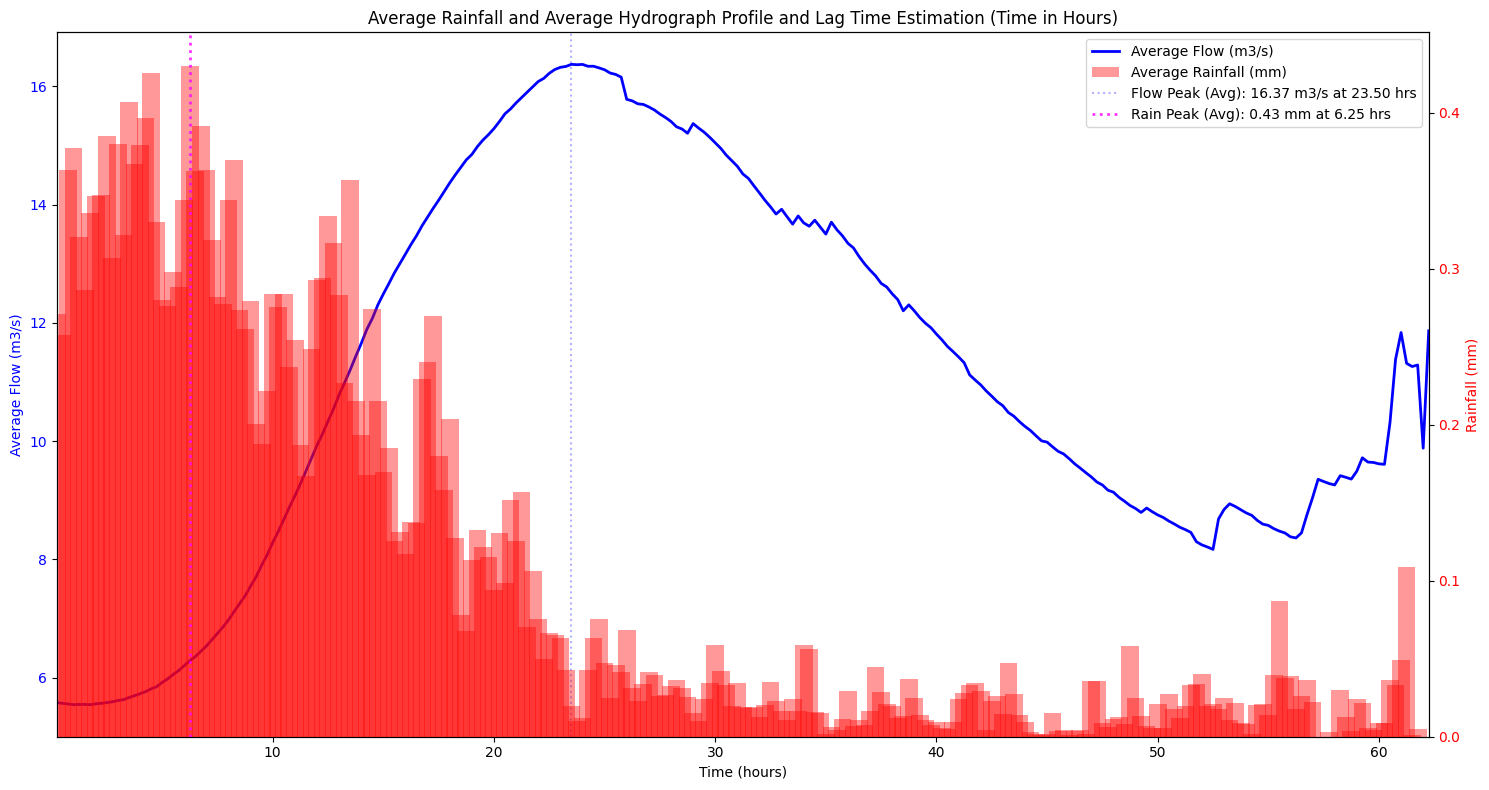

In [ ]:
import matplotlib.pyplot as plt

# Create the figure and subplots
fig, ax1 = plt.subplots(figsize=(15, 8))

# Plot 'Average_Flow' on the primary y-axis (ax1)
line_flow, = ax1.plot(df_events_average['Time'] / time_units_hour, df_events_average['Average_Flow'], color='blue', label='Average Flow (m3/s)', linewidth=2)
ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('Average Flow (m3/s)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a secondary y-axis (ax2) for rainfall
ax2 = ax1.twinx()
bar_rain = ax2.bar(df_events_average['Time'] / time_units_hour, df_events_average['Average_Rain'], color='red', alpha=0.4, label='Average Rainfall (mm)')
ax2.set_ylabel('Rainfall (mm)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add markers for both peaks, converting time index to hours
line_flow_peak = ax1.axvline(peak_avg_flow_time / time_units_hour, color='blue', alpha=0.3, linestyle=':', label=f'Flow Peak (Avg): {peak_avg_flow_value:.2f} m3/s at {peak_avg_flow_time_hours:.2f} hrs')
line_rain_peak = ax2.axvline(peak_avg_rain_time / time_units_hour, color='magenta', alpha=0.8, linestyle=':', linewidth=2, label=f'Rain Peak (Avg): {peak_avg_rain_value:.2f} mm at {peak_avg_rain_time_hours:.2f} hrs')

# Set x-axis limits based on the actual data range
ax1.set_xlim(x_axis_values.min(), x_axis_values.max())

# Titles and Legends
plt.title('Average Rainfall and Average Hydrograph Profile and Lag Time Estimation (Time in Hours)')

# Manually define the order of handles and labels for the legend
handles = [line_flow, bar_rain, line_flow_peak, line_rain_peak]
labels = [
    'Average Flow (m3/s)',
    'Average Rainfall (mm)',
    f'Flow Peak (Avg): {peak_avg_flow_value:.2f} m3/s at {peak_avg_flow_time_hours:.2f} hrs',
    f'Rain Peak (Avg): {peak_avg_rain_value:.2f} mm at {peak_avg_rain_time_hours:.2f} hrs'
]

ax1.legend(handles, labels, loc='upper right')

#ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Export of Results



In [ ]:
# Define average hydrograph timeseries output file path
final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Bollin_average_hydrograph.csv'

# Save the average hydrograph to CSV
df_events_average.to_csv(final_output_path)

print(f'Successfully saved event adjusted results to: {final_output_path}')

Successfully saved event adjusted results to: /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Bollin_average_hydrograph.csv


# Lag Time Estimation

Definition:
* Lag = time difference between:
  * Peak rainfall
  * Peak flow

Output:
* Lag in:
  * Hours
  * Hours + minutes

### Calculate Lag Time (Hours)

In [ ]:
# Calculate the difference in Time index
lag_time_hours = peak_avg_flow_time_hours - peak_avg_rain_time_hours

# Print the results to verify
print(f'Average Hydrograph Lag Time: {lag_time_hours} hours (from start)')

# Convert average hydrogragh Peak Time to hours an minuties
total_peak_minutes = lag_time_hours * 60
average_hydrograph_lag_time_hours = int(total_peak_minutes // 60)
average_hyrograph_lag_time_minutes = int(total_peak_minutes % 60)

print(f'Average Hydrograph Lag Time: {average_hydrograph_lag_time_hours} hours and {average_hyrograph_lag_time_minutes} minutes (from start)')

Average Hydrograph Lag Time: 17.25 hours (from start)
Average Hydrograph Lag Time: 17 hours and 15 minutes (from start)


### Create Dictionary of Average Hydrograph Metrics and Export Results

In [ ]:
# Create a new DataFrame to store result values
average_hydrograph_summary_data = {

    'Average Flow Peak (m3/s)': [peak_avg_flow_value],
    'Time of Average Peak Flow (hours)': [peak_avg_flow_time_hours],
    'Average Rainfall Peak (mm)': [peak_avg_rain_value],
    'Time of Average Rainfall Peak (hours)': [peak_avg_rain_time_hours],
    'Average Lag Time (hours)': [lag_time_hours]


}
average_hydrograph_summary_df = pd.DataFrame(average_hydrograph_summary_data)

# Round numerical columns for better display
average_hydrograph_summary_df = average_hydrograph_summary_df.round({
    'Average Flow Peak (m3/s)': 2,
    'Time of Average Peak Flow (hours)': 2,
    'Average Rainfall Peak (mm)': 2,
    'Time of Average Rainfall Peak (hours)': 2,
    'Average Lag Time (hours)': 2

})

# Display the summary DataFrame
pd.set_option('display.width', 500)
display(average_hydrograph_summary_df)


# Define the final output file path for the complete event analysis
final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Metrics/Bollin_Peaks_Timing_Lags_analysis_results_events_average_hydrograph.csv'
#final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Metrics/Bollin_Peaks_Timing_Lags_analysis_results_events_before_average_hydrograph.csv'
# final_output_path = '/content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Metrics/Bollin_Peaks_Timing_Lags_analysis_results_events_after_average_hydrograph.csv'

# Save the mean_summary_df to CSV
average_hydrograph_summary_df.to_csv(final_output_path, index=False)

print(f'Successfully saved event analysis results to: {final_output_path}')

,Average Flow Peak (m3/s),Time of Average Peak Flow (hours),Average Rainfall Peak (mm),Time of Average Rainfall Peak (hours),Average Lag Time (hours)
0,16.37,23.5,0.43,6.25,17.25


Successfully saved event analysis results to: /content/drive/MyDrive/dataset/Hydro_Analysis/Output/Multiple Events/Metrics/Bollin_Peaks_Timing_Lags_analysis_results_events_average_hydrograph.csv


# Comparison: Individual vs Average Hydrograph

Plot:
* All individual events (thin blue lines)
* Average hydrograph (thick black line)

#### Plot All Events with Average Profile

Create a figure plotting all individual event flow series as thin lines and overlay the 'Average_Flow' as a thick black line.


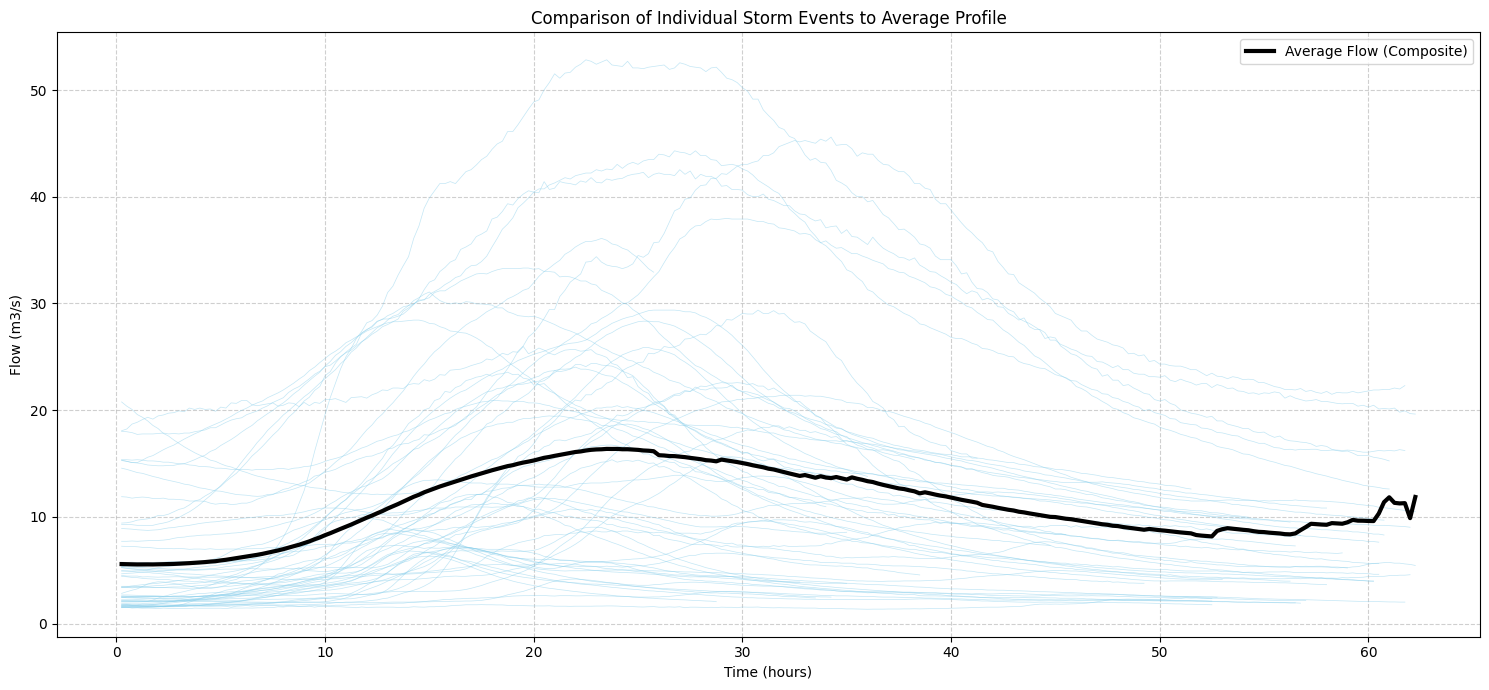

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and axis with a large size for clarity
fig, ax = plt.subplots(figsize=(15, 7))

# Iterate through each individual flow column and plot as thin light lines
for col in flow_columns:
    ax.plot(df_events['Time'] / time_units_hour, df_events[col], color='skyblue', linewidth=0.5, alpha=0.5)

# Plot the Average_Flow as a thick black line
ax.plot(df_events_average['Time'] / time_units_hour, df_events_average['Average_Flow'], color='black', linewidth=3, label='Average Flow (Composite)')

# Set plot aesthetics
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Flow (m3/s)')
ax.set_title('Comparison of Individual Storm Events to Average Profile')

# Add a legend to highlight the average profile
ax.legend(loc='upper right')

# Add grid for better readability
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Uncertainty Analysis (95% Confidence Interval)

Steps:
* Compute standard deviation across events
* Compute standard error (SEM):
* Compute 95% CI: Mean ± 1.96 ⋅SEM

#### Calculate 95% Confidence Intervals

Compute the Standard Error of the Mean (SEM) and 95% Confidence Intervals for the average flow profile.


In [ ]:
import numpy as np

# Calculate row-wise standard deviation for flow columns
flow_std = df_events[flow_columns].std(axis=1)

# Calculate Standard Error of the Mean (SEM)
n_events = len(flow_columns)
flow_sem = flow_std / np.sqrt(n_events)

# Calculate 95% Confidence Intervals (CI)
# Formula: Mean +/- (1.96 * SEM)
df_events_average['Flow_CI_Upper'] = df_events_average['Average_Flow'] + (1.96 * flow_sem)
df_events_average['Flow_CI_Lower'] = df_events_average['Average_Flow'] - (1.96 * flow_sem)

# Print results to verify
print('Verification of 95% Confidence Intervals for Flow:')
print(df_events_average[['Time', 'Average_Flow', 'Flow_CI_Lower', 'Flow_CI_Upper']].head())

# Check for null values at the end of the series
print('\nNull values in Flow_CI_Lower:', df_events_average['Flow_CI_Lower'].isnull().sum())
print('Null values in Flow_CI_Upper:', df_events_average['Flow_CI_Upper'].isnull().sum())

Verification of 95% Confidence Intervals for Flow:
   Time  Average_Flow  Flow_CI_Lower  Flow_CI_Upper
0     1      5.576373       4.163380       6.989365
1     2      5.565059       4.160696       6.969421
2     3      5.552157       4.151329       6.952984
3     4      5.541627       4.149166       6.934089
4     5      5.546137       4.152733       6.939541

Null values in Flow_CI_Lower: 0
Null values in Flow_CI_Upper: 0


#### Plot Average Hydrograph with Confidence Intervals

Re-generate the flow hydrograph to visualize the 95% Confidence Interval alongside individual events and the average profile.


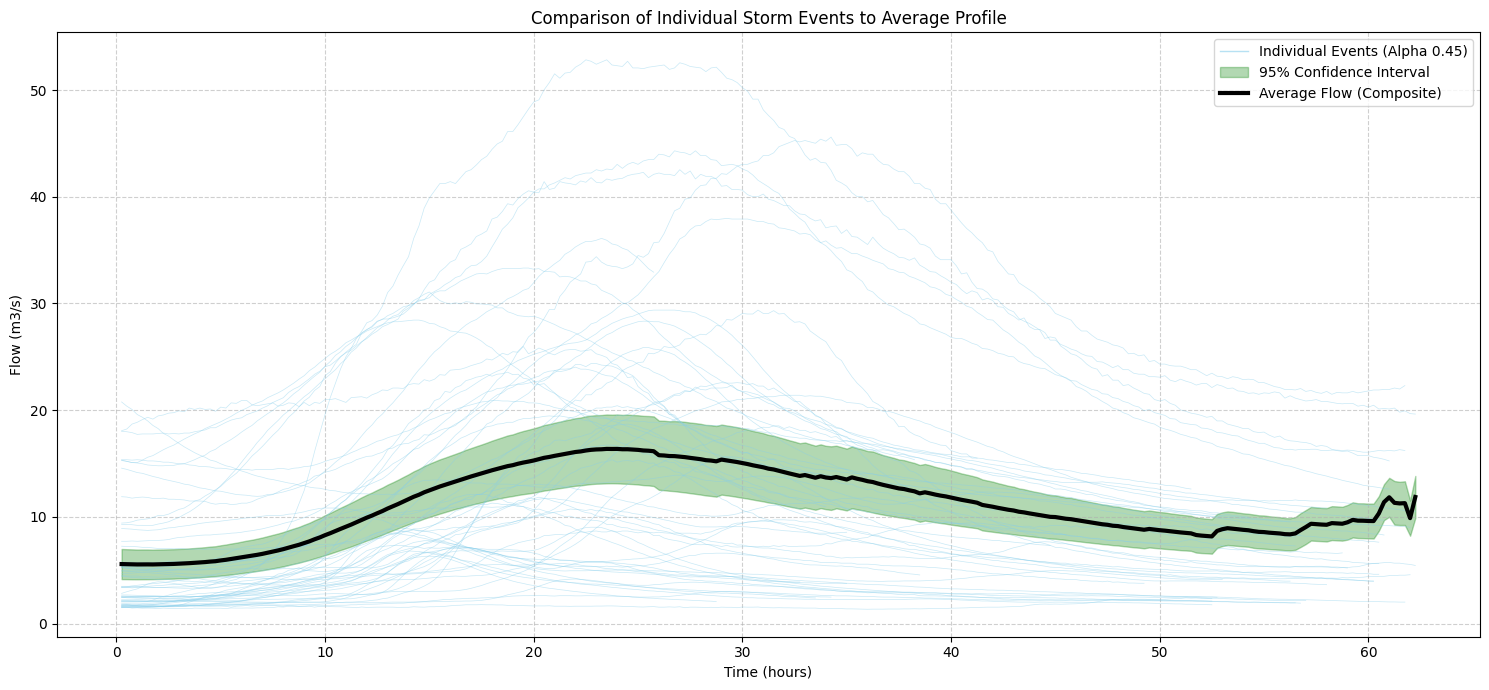

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and axis object
fig, ax = plt.subplots(figsize=(15, 7))

# Plot individual event series with higher opacity (alpha=0.45)
# Using flow_columns identified in previous steps
for col in flow_columns:
    ax.plot(df_events['Time'] / 4, df_events[col], color='skyblue', linewidth=0.5, alpha=0.45, label='_nolegend_')

# Add a dummy line for the legend to represent individual events
ax.plot([], [], color='skyblue', linewidth=1, alpha=0.6, label='Individual Events (Alpha 0.45)')

# Shade the 95% Confidence Interval (precision of the mean)
ax.fill_between(df_events_average['Time'] / time_units_hour, df_events_average['Flow_CI_Lower'], df_events_average['Flow_CI_Upper'], color='green', alpha=0.3, label='95% Confidence Interval')

# Plot the Average_Flow as a thick black line
ax.plot(df_events_average['Time'] / time_units_hour, df_events_average['Average_Flow'], color='black', linewidth=3, label='Average Flow (Composite)')

# Set plot aesthetics
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Flow (m3/s)')
ax.set_title('Comparison of Individual Storm Events to Average Profile')

# Add legend and grid
ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

CHECK this code

In [ ]:
# Filter df_events_average to include data up to and including the average flow peak time index
# Using peak_avg_flow_idx (which is 0-indexed) means we select up to and including this row.
rainfall_before_flow_peak_df = df_events_average.loc[:peak_avg_flow_idx].copy()

# Calculate the sum of rainfall before or at the average hydrograph peak
sum_rainfall_before_flow_peak = rainfall_before_flow_peak_df['Average_Rain'].sum()
print(f"Sum of Average Rainfall before/at Average Flow Peak: {sum_rainfall_before_flow_peak:.2f} mm\n")

# Calculate the centroid of the rainfall before or at the average hydrograph peak
# Ensure there's actual rainfall to avoid division by zero
if sum_rainfall_before_flow_peak > 0:
    centroid_rainfall_before_flow_peak_time_idx = (rainfall_before_flow_peak_df['Time'] * rainfall_before_flow_peak_df['Average_Rain']).sum() / sum_rainfall_until_flow_peak
else:
    centroid_rainfall_before_flow_peak_time_idx = np.nan # Handle cases with no rainfall

# Convert centroid time index to hours
centroid_rainfall_before_flow_peak_time_hours = (centroid_rainfall_before_flow_peak_time_idx * time_interval_min) / 60

print(f'Average Rainfall Centroid (up to Flow Peak - Time Index): {centroid_rainfall_before_flow_peak_time_idx:.2f}')
print(f'Average Rainfall Centroid (up to Flow Peak - Hours): {centroid_rainfall_before_flow_peak_time_hours:.2f} hours\n')

# 3. Calculate the lag between the average rainfall centroid and average peak flow
lag_time_centroid_before_flow_peak_hours = peak_avg_flow_time_hours - centroid_rainfall_before_flow_peak_time_hours

print(f'Average Hydrograph Lag Time (using Rainfall Centroid up to Flow Peak): {lag_time_centroid_before_flow_peak_hours:.2f} hours')

# Convert to hours and minutes for better readability
total_peak_minutes_centroid_before_flow_peak = lag_time_centroid_before_flow_peak_hours * 60
centroid_lag_before_flow_peak_hours_hr = int(total_peak_minutes_centroid_before_flow_peak // 60)
centroid_lag_before_flow_peak_minutes = int(total_peak_minutes_centroid_before_flow_peak % 60)

print(f'Average Hydrograph Lag Time (using Rainfall Centroid up to Flow Peak): {centroid_lag_before_flow_peak_hours_hr} hours and {centroid_lag_until_flow_peak_minutes} minutes')


Sum of Average Rainfall before/at Average Flow Peak: 22.12 mm

Average Rainfall Centroid (up to Flow Peak - Time Index): 36.97
Average Rainfall Centroid (up to Flow Peak - Hours): 9.24 hours

Average Hydrograph Lag Time (using Rainfall Centroid up to Flow Peak): 14.26 hours
Average Hydrograph Lag Time (using Rainfall Centroid up to Flow Peak): 14 hours and 15 minutes


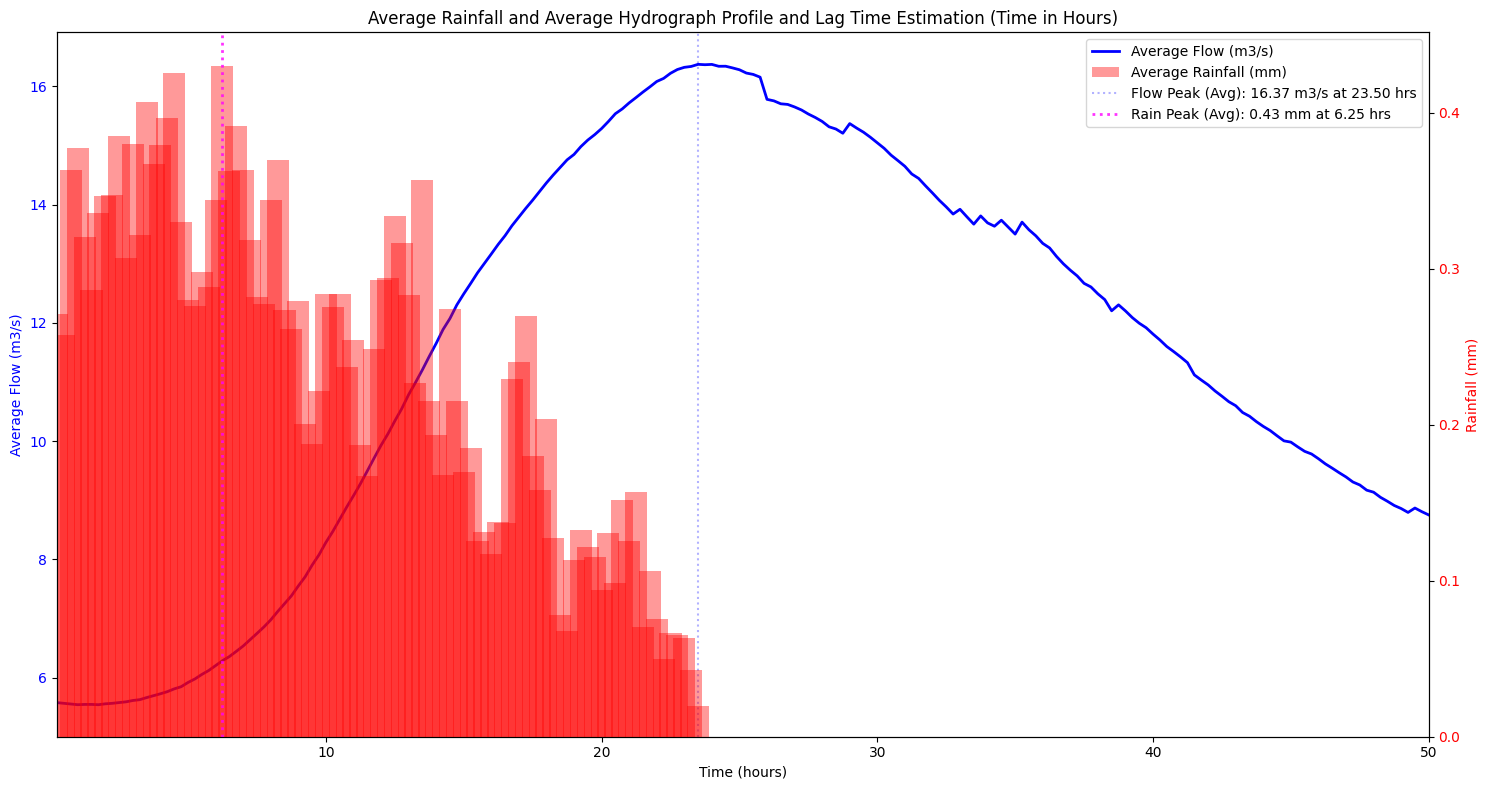

In [ ]:
import matplotlib.pyplot as plt

# Create the figure and subplots
fig, ax1 = plt.subplots(figsize=(15, 8))

# Plot 'Average_Flow' on the primary y-axis (ax1)
line_flow, = ax1.plot(df_events_average['Time'] / 4, df_events_average['Average_Flow'], color='blue', label='Average Flow (m3/s)', linewidth=2)
ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('Average Flow (m3/s)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a secondary y-axis (ax2) for rainfall
ax2 = ax1.twinx()
bar_rain = ax2.bar(rainfall_before_flow_peak_df['Time'] / 4, rainfall_before_flow_peak_df['Average_Rain'], color='red', alpha=0.4, label='Average Rainfall (mm)')
ax2.set_ylabel('Rainfall (mm)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add markers for both peaks, converting time index to hours
line_flow_peak = ax1.axvline(peak_avg_flow_time / 4, color='blue', alpha=0.3, linestyle=':', label=f'Flow Peak (Avg): {peak_avg_flow_value:.2f} m3/s at {peak_avg_flow_time_hours:.2f} hrs')
line_rain_peak = ax2.axvline(peak_avg_rain_time / 4, color='magenta', alpha=0.8, linestyle=':', linewidth=2, label=f'Rain Peak (Avg): {peak_avg_rain_value:.2f} mm at {peak_avg_rain_time_hours:.2f} hrs')

# Set x-axis limits based on the actual data range
ax1.set_xlim(x_axis_values.min(), x_axis_values.max())

# Titles and Legends
plt.title('Average Rainfall and Average Hydrograph Profile and Lag Time Estimation (Time in Hours)')

# Manually define the order of handles and labels for the legend
handles = [line_flow, bar_rain, line_flow_peak, line_rain_peak]
labels = [
    'Average Flow (m3/s)',
    'Average Rainfall (mm)',
    f'Flow Peak (Avg): {peak_avg_flow_value:.2f} m3/s at {peak_avg_flow_time_hours:.2f} hrs',
    f'Rain Peak (Avg): {peak_avg_rain_value:.2f} mm at {peak_avg_rain_time_hours:.2f} hrs'
]

ax1.legend(handles, labels, loc='upper right')

#ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()